# 非線形CLN、FP-CLNと表面モード

## 固定するものと、更新するもの

非線形磁性体で$H(B)=\nu_*B+r(B)$と分解すると、一定係数側で場の基底を作り、非線形残差$r(B)$を基底へ射影する構成が考えられます。回路係数・基底を固定しても、右辺の補正源は反復ごとに変わります。単に透磁率を一定にしたモデルではありません。

表面モードは、導体外部の磁界の寄与を少数の境界自由度で表すものです。線形な外部領域を消去したSchur補行列をSとすれば、概念的に
$$M\dot x+(K_*+S)x=Bu-f_{\rm nl}(x),\quad x\simeq Qa$$
となります。体積CLNの段数、表面モード数、時間刻み、非線形反復許容誤差は、別々の近似パラメータです。

## 最小の実行例：固定点補正と表面の切捨てを分ける

以下は3自由度の**説明用の非線形モード系**です。CLN生成や磁性体FEMではありません。線形核K、表面の寄与S、非線形項$0.2\tanh(x)$を用いて、Sを切り捨てた誤差と固定点反復の残差を区別します。Sはこの例では対角で、並び順は重要度を表すものではありません。


kept=0: fixed-point residual=5.07e-13; model error=3.671e-01
kept=1: fixed-point residual=4.64e-13; model error=3.519e-01
kept=2: fixed-point residual=2.42e-13; model error=3.148e-01
kept=3: fixed-point residual=2.02e-13; model error=0.000e+00


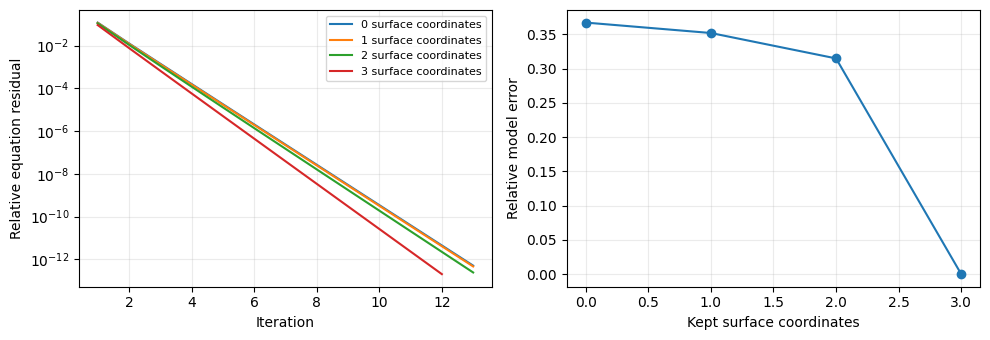

In [1]:
import numpy as np
import matplotlib.pyplot as plt
K=np.array([[2.,-.3,0],[-.3,2.,-.2],[0,-.2,1.5]])
surface=np.array([.2,.5,1.])
b=np.array([1.,.5,.8])
def solve(kept):
    S=np.diag(np.where(np.arange(3)<kept,surface,0))
    A=K+S
    assert .2/np.linalg.eigvalsh(A).min()<1 # contraction bound for this example
    x=np.zeros(3);history=[]
    for iteration in range(200):
        x=np.linalg.solve(A,b-.2*np.tanh(x))
        residual=np.linalg.norm(A@x+.2*np.tanh(x)-b)/np.linalg.norm(b)
        history.append(residual)
        if residual<1e-12:return x,history
    raise RuntimeError('Fixed point did not converge')
reference,_=solve(3)
fig,ax=plt.subplots(1,2,figsize=(10,3.5))
errors=[]
for kept in range(4):
    value,history=solve(kept)
    errors.append(np.linalg.norm(value-reference)/np.linalg.norm(reference))
    ax[0].semilogy(range(1,len(history)+1),history,label=f'{kept} surface coordinates')
    print(f'kept={kept}: fixed-point residual={history[-1]:.2e}; model error={errors[-1]:.3e}')
ax[0].set(xlabel='Iteration',ylabel='Relative equation residual');ax[0].legend(fontsize=8)
ax[1].plot(range(4),errors,'o-');ax[1].set(xlabel='Kept surface coordinates',ylabel='Relative model error')
for a in ax:a.grid(alpha=.25)
plt.tight_layout();plt.show()


すべての反復が収束しても、表面を省略したモデルが正しいとは限りません。逆に、特定モデルで表面モードが有効だったことから、すべてのFP-CLNに同じ表面表現が必須だとは言えません。

## 実際の研究実装へ繋ぐ

既存の研究実装には、丸棒・角柱の表面縮約と、非線形FP-CLNの保存結果があります。公開用の再現では以下を独立に変化させます。

| 変化させるもの | 調べる誤差 |
|---|---|
| 全自由度とCLN基底数 | 体積の縮約誤差 |
| 全表面自由度と表面モード数 | 外部磁界の近似誤差 |
| 時間刻み・計算周期 | 時間離散化・過渡の影響 |
| 固定点係数・反復許容誤差 | 非線形solveの誤差と収束性 |
| 追加ポート・非線形源の基底 | 単一励振で捉えられない空間パターン |

磁束鎖交数だけでなく、周期損失・場の残差も比較します。Anderson加速は収束保証そのものではありません。非線形の保存的構成則のエネルギーは$\int H\cdot dB$であり、一般に$BH/2$ではありません。ヒステリシスを含む場合は履歴と散逸を別に扱います。

このリリースの上の図は説明用モード系の結果です。研究用FP-CLNの定量ベンチマークとして引用しないでください。関連する既往研究として [非線形CLNの一次近似](https://doi.org/10.1109/TMAG.2019.2946354) がありますが、上の説明用反復はその論文の再現ではありません。
